In [ ]:
import torch
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
torch.set_default_device('cuda')

In [ ]:
def generate_angle_vector(beta_star, angle_degrees):
  """
  Generates a unit-norm vector at a specified angle to beta_star.

  Args:
    beta_star: The input vector.
    angle_degrees: The desired angle in degrees.

  Returns:
    A unit-norm vector at the specified angle to beta_star.
  """

  beta_star = beta_star.reshape(-1)

  # Generate a random vector
  random_vector = torch.randn(beta_star.shape)

  # Orthogonalize the random vector to beta_star using Gram-Schmidt
  orthogonal_vector = random_vector - (torch.dot(random_vector, beta_star) / torch.dot(beta_star, beta_star)) * beta_star

  # Normalize the orthogonal vector
  orthogonal_vector = orthogonal_vector / torch.norm(orthogonal_vector)

  # Convert angle to radians
  angle_radians = torch.deg2rad(torch.tensor(angle_degrees))

  # Create the angled vector
  angled_vector = torch.cos(angle_radians) * (beta_star / torch.norm(beta_star)) + torch.sin(angle_radians) * orthogonal_vector

  return angled_vector.reshape(-1,1)

In [ ]:
def bias_theory(n, d, tau, beta_star, u, theta, theta_t, alpha_A, alpha_A_t, alpha_Z, alpha_Z_t, tau_e):
  c = d/n
  if c < 1:
    den = theta**2 * c + tau**2
    coeff = alpha_Z_t - alpha_Z +  (tau**2 / den) * (alpha_Z - alpha_A)
    term1 = coeff**2 * (beta_star.T @ u)**2
    term2 = tau_e**2 * (c/(1-c)) * (1/den)
    term3 = 0 # (alpha_Z - alpha_A) ** 2 * (c/(1-c)) * (tau**2 * theta**2 /den**2) * (beta_star.T @ u)**2
    return theta_t ** 2 * (term1 + term2 + term3) / n
  else:
    den = theta**2 + tau**2
    coeff = alpha_Z_t - alpha_Z + (tau**2 / den)  * (alpha_Z - alpha_A/c)
    term1 = (coeff**2 + (1/(c-1)) * (theta**2 * tau**2 / (n * den **2)) * (alpha_Z - alpha_A/c)**2) * (beta_star.T @ u)**2
    term2 = tau_e**2 * ((1/((c-1)) * (theta**2 * c + tau**2) / (theta**2 + tau**2)**2) + ((theta**2 / (n * (theta**2 + tau**2)**2)) * (1/((c-1)**2))))
    term3 = alpha_A ** 2 * (1-1/c) * (beta_star.square().sum()/d) * (tau**2 * theta**2 / den**2)
    return theta_t ** 2 * (term1 + term2 + term3) / n

def noise_theory(n, d, tau, beta_star, u, theta, theta_t, alpha_A, alpha_A_t, alpha_Z, alpha_Z_t, tau_e):
  return tau**2 * alpha_A_t**2 * (beta_star).square().sum()/d

def variance_theory(n, d, tau, beta_star, u, theta, theta_t, alpha_A, alpha_A_t, alpha_Z, alpha_Z_t, tau_e):
  c = d/n
  coeff = (beta_star.T @ u)**2
  if c < 1:
    return tau**2/d * (
        alpha_Z**2 * (((theta**4 + theta**2 * tau**2)/(theta**2 * c + tau**2 )**2) * c**2/(1-c) * coeff) +
        alpha_A**2 * (torch.norm(beta_star)**2 + ( ((theta**4 + theta**2 * tau**2)/(theta**2 * c + tau**2 )**2 * c**2/(1-c)
              - 2 * theta**2 * c/(theta**2 * c + tau**2 ))*coeff)) +
        2*alpha_A*alpha_Z * (- ( ((theta**4 + theta**2 * tau**2)/(theta**2 * c + tau**2 )**2 * c**2/(1-c) - theta**2*c/(theta**2 * c + tau**2 ) ) * coeff)) +
        tau_e**2 * (c*d/(tau**2 * (1-c)) - theta**2 / (tau**2 * (theta**2*c + tau**2)) * c**2 /(1 - c))
    )
  else:
    return tau**2/d * (
        alpha_Z**2 * ((theta**2/(theta**2 + tau**2 )) * c/(c-1) * coeff) +
        alpha_A**2 * (torch.norm(beta_star)**2/c - (theta**2/(theta**2 + tau**2 ) * (torch.norm(beta_star)**2/d - coeff/(c*(c - 1)) ) )) +
        2*alpha_A*alpha_Z * (- (theta**2/(theta**2 + tau**2 ) * ( coeff/(c - 1)) )) +
        tau_e**2 * (d/(tau**2 * (c-1)) - theta**2 / (tau**2 * (theta**2 + tau**2)) * c /(c - 1))
    )

def alignment_theory(n, d, tau, beta_star, u, theta, theta_t, alpha_A, alpha_A_t, alpha_Z, alpha_Z_t, tau_e):
  c = d/n
  if c < 1:
    return -2*alpha_A_t*tau**2/d * ((alpha_Z-alpha_A) * (theta**2 * c)/(tau**2 + theta**2 * c) * (beta_star.T @ u) ** 2 + alpha_A * (beta_star.square().sum()))
  else:
    return -2*alpha_A_t*tau**2/d * ((alpha_Z-alpha_A/c) * (theta**2)/(tau**2 + theta**2) * (beta_star.T @ u) ** 2 + alpha_A * (beta_star.square().sum()) * (1/c - theta**2/(d * (theta**2 + tau**2))))

def theory(n, d, tau, beta_star, u, theta, theta_t, alpha_A, alpha_A_t, alpha_Z, alpha_Z_t, tau_e):
  return (bias_theory(n, d, tau, beta_star, u, theta, theta_t, alpha_A, alpha_A_t, alpha_Z, alpha_Z_t, tau_e) +
          noise_theory(n, d, tau, beta_star, u, theta, theta_t, alpha_A, alpha_A_t, alpha_Z, alpha_Z_t, tau_e) +
          variance_theory(n, d, tau, beta_star, u, theta, theta_t, alpha_A, alpha_A_t, alpha_Z, alpha_Z_t, tau_e) +
          alignment_theory(n, d, tau, beta_star, u, theta, theta_t, alpha_A, alpha_A_t, alpha_Z, alpha_Z_t, tau_e))

In [ ]:
d = 1000
tau = 1 #np.sqrt(d)
# theta = np.sqrt(d)
# theta_t = np.sqrt(d)
n = 1000

alpha_A = 1
alpha_A_t = 1
alpha_Z = 1
alpha_Z_t = 1
tau_e = 1

beta_star = torch.randn(d,1)
beta_star = beta_star/torch.norm(beta_star)

T = 50

In [ ]:
def error_fnc(d,n,tau,u,v,v_t,beta_star,alpha_A,alpha_A_t,alpha_Z,alpha_Z_t,tau_e,theta,theta_t):
  c = d/n
  A = torch.randn(d,n) * (np.sqrt(c) * tau / np.sqrt(d))
  Z = theta * u @ v.T
  X = Z + A

  y = beta_star.T @ (alpha_Z * Z + alpha_A * A)
  y = y + torch.randn_like(y) * tau_e
  beta = (y @ torch.linalg.pinv(X)).T

  A_t = torch.randn(d,n) * (np.sqrt(c) * tau / np.sqrt(d))
  Z_t = theta_t * u @ v_t.T
  X_t = alpha_Z_t * Z_t + alpha_A_t * A_t
  y_t = beta_star.T @ X_t

  y_p = beta.T @ (Z_t + A_t)

  return y_p,y_t,beta,A_t,Z_t

In [ ]:
Ns = [10,20,30,40,50,100,200,300,500,600,700,800]
errors = torch.zeros(len(Ns))
errors_anti = torch.zeros(len(Ns))
error_decomp = torch.zeros(4,len(Ns))

bias_theory_formula = torch.zeros(len(Ns))
noise_theory_formula = torch.zeros(len(Ns))
variance_theory_formula = torch.zeros(len(Ns))
alignment_theory_formula = torch.zeros(len(Ns))

theorys = torch.zeros(len(Ns))
theorys_anti = torch.zeros(len(Ns))
theorys_decomp = torch.zeros(4,len(Ns))

u = generate_angle_vector(beta_star, 0)
u_anti = generate_angle_vector(beta_star, 90)

align = (beta_star.T @ u)**2
Delta = (alpha_A - alpha_Z)

print(align, Delta)

for i,n in tqdm(list(enumerate(Ns))):
  c = d/n

  v = torch.randn(n,1)
  v = v/torch.norm(v)

  v_t = torch.randn(n,1)
  v_t = v_t/torch.norm(v_t)

  theta = np.sqrt(c)*tau
  theta_t = np.sqrt(c)*tau

  theorys[i] = theory(n, d, tau, beta_star, u, theta, theta_t, alpha_A, alpha_A_t, alpha_Z, alpha_Z_t, tau_e)
  theorys_anti[i] = theory(n, d, tau, beta_star, u_anti, theta, theta_t, alpha_A, alpha_A_t, alpha_Z, alpha_Z_t, tau_e)

  theorys_decomp[0,i] = bias_theory(n, d, tau, beta_star, u, theta, theta_t, alpha_A, alpha_A_t, alpha_Z, alpha_Z_t, tau_e)
  theorys_decomp[1,i] = noise_theory(n, d, tau, beta_star, u, theta, theta_t, alpha_A, alpha_A_t, alpha_Z, alpha_Z_t, tau_e)
  theorys_decomp[2,i] = variance_theory(n, d, tau, beta_star, u, theta, theta_t, alpha_A, alpha_A_t, alpha_Z, alpha_Z_t, tau_e)
  theorys_decomp[3,i] = alignment_theory(n, d, tau, beta_star, u, theta, theta_t, alpha_A, alpha_A_t, alpha_Z, alpha_Z_t, tau_e)
  for _ in range(T):

    y_p,y_t,beta,A_t,Z_t = error_fnc(d,n,tau,u,v,v_t,beta_star,alpha_A,alpha_A_t,alpha_Z,alpha_Z_t,tau_e,theta,theta_t)
    errors[i] += (y_p - y_t).square().sum()/(n*T)

    error_decomp[0, i] += (beta_star.T @ (alpha_Z_t * Z_t) - beta.T @ Z_t).square().sum()/(n*T)
    error_decomp[1, i] += (alpha_A_t * beta_star.T @ A_t).square().sum()/(n*T)
    error_decomp[2, i] += (beta.T @ A_t).square().sum()/(n*T)
    error_decomp[3, i] -= 2*(alpha_A_t * beta_star.T @ A_t @ A_t.T @ beta).item()/(n*T)

    y_p,y_t,beta,A_t,Z_t  = error_fnc(d,n,tau,u_anti,v,v_t,beta_star,alpha_A,alpha_A_t,alpha_Z,alpha_Z_t,tau_e,theta,theta_t)
    errors_anti[i] += (y_p - y_t).square().sum()/(n*T)



tensor([[1.]], device='cuda:0') 0


100%|██████████| 12/12 [00:17<00:00,  1.49s/it]


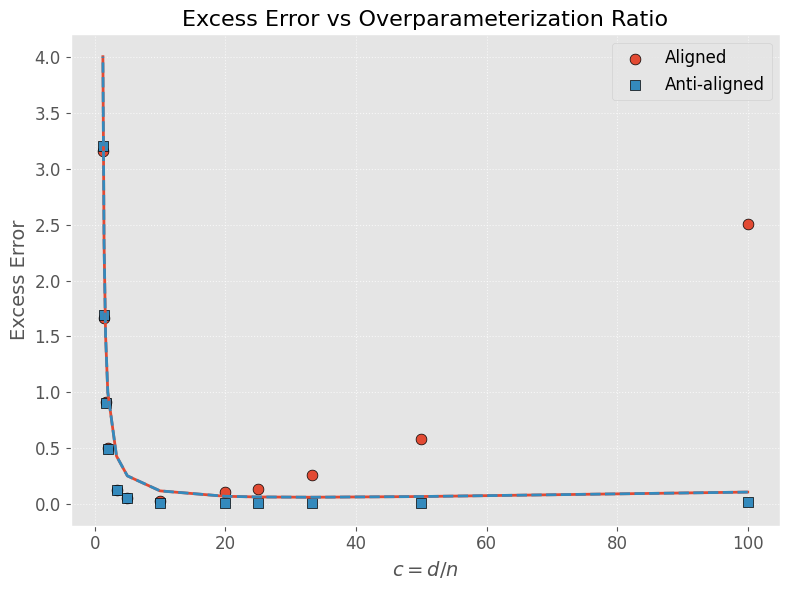

In [ ]:
import matplotlib.pyplot as plt

# Option A: use a built-in Matplotlib style
plt.style.use("ggplot")     # or "bmh", "seaborn", etc.

# Option B (if you have seaborn installed):
# import seaborn as sns
# sns.set_style("whitegrid")

# Prepare your data as NumPy arrays for plotting
c = (d/torch.tensor(Ns)).cpu().numpy()
err = errors.cpu().numpy()
th = theorys.cpu().numpy()
err_anti = errors_anti.cpu().numpy()
th_anti = theorys_anti.cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 6))

# Aligned
ax.scatter(c, err,
           marker='o', s=60, edgecolor='k', label="Aligned")
ax.plot(c, th,
        linestyle='-', linewidth=2)

# Anti-aligned
ax.scatter(c, err_anti,
           marker='s', s=60, edgecolor='k', label="Anti-aligned")
ax.plot(c, th_anti,
        linestyle='--', linewidth=2)

ax.set_xlabel(r"$c = d/n$", fontsize=14)
ax.set_ylabel("Excess Error", fontsize=14)
ax.set_title("Excess Error vs Overparameterization Ratio", fontsize=16)

# ax.axvline(x = 2, label = r"$c = 2$", color = "green")
# ax.axvline(x = 9/2 + np.sqrt(57)/2, label = r"$c = \frac{9 + \sqrt{57}}{2}$", color = "green")

ax.legend(fontsize=12, frameon=True)

ax.grid(True, linestyle=":", alpha=0.7)
ax.tick_params(axis="both", which="major", labelsize=12)

# plt.yscale("log")
# plt.xscale("log")

plt.tight_layout()

plt.savefig("error_vs_c-operator-norm-alpha_A-"+str(alpha_A)+"-alpha_Z-"+str(alpha_Z)+"-theta=tau.png", dpi=100)

plt.show()

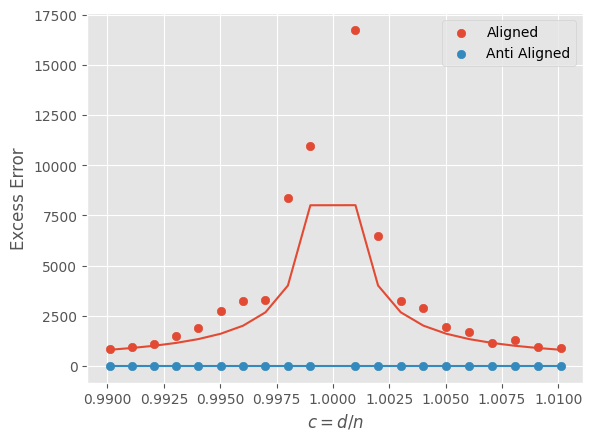

In [ ]:
plt.scatter(d/torch.tensor(Ns).cpu(), errors.cpu(), label="Aligned")
plt.plot(d/torch.tensor(Ns).cpu(), theorys.cpu())
plt.scatter(d/torch.tensor(Ns).cpu(), errors_anti.cpu(), label="Anti Aligned")
plt.plot(d/torch.tensor(Ns).cpu(), theorys_anti.cpu())
plt.xlabel(r"$c = d/n$")
plt.ylabel("Excess Error")
plt.legend()

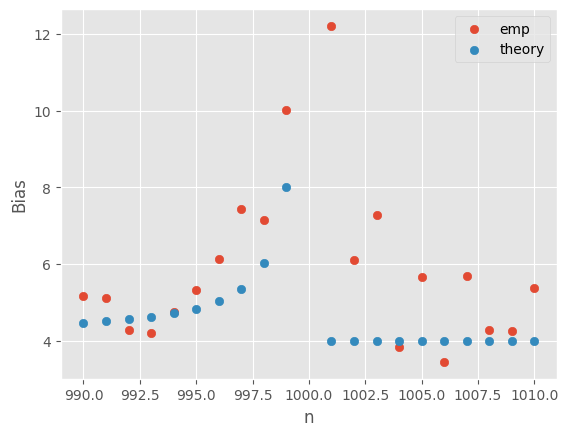

In [ ]:
plt.scatter(Ns, error_decomp[0,:].cpu(), label="emp")
plt.scatter(Ns, theorys_decomp[0,:].cpu(), label='theory')
plt.ylabel("Bias")
plt.xlabel("n")
plt.legend()

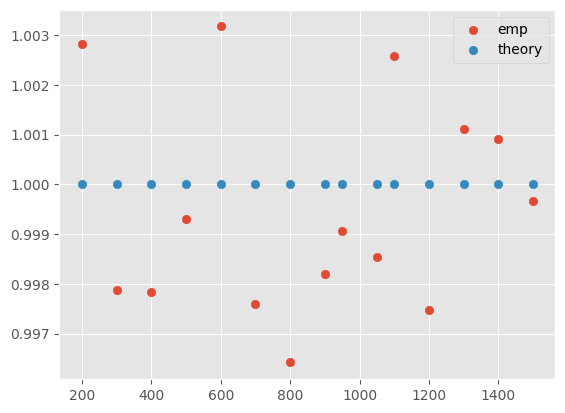

In [ ]:
plt.scatter(Ns, error_decomp[1,:].cpu(), label="emp")
plt.scatter(Ns, theorys_decomp[1,:].cpu(), label='theory')
plt.legend()

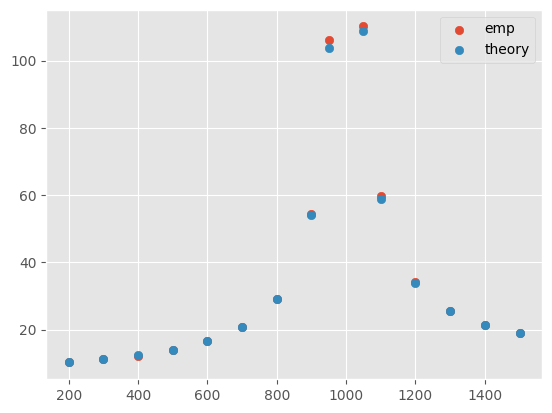

In [ ]:
plt.scatter(Ns, error_decomp[2,:].cpu(), label="emp")
plt.scatter(Ns, theorys_decomp[2,:].cpu(), label='theory')
plt.legend()

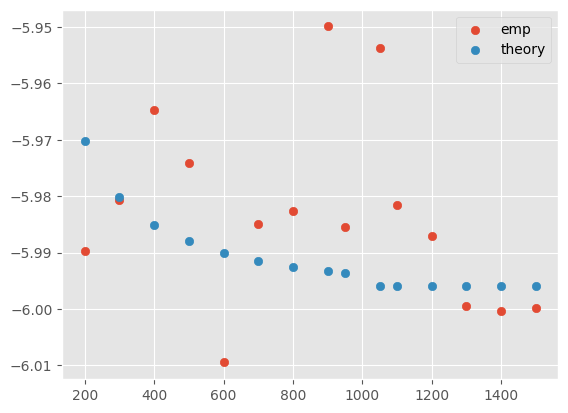

In [ ]:
plt.scatter(Ns, error_decomp[3,:].cpu(), label="emp")
plt.scatter(Ns, theorys_decomp[3,:].cpu(), label='theory')
plt.legend()

In [ ]:
errors

tensor([ 0.6872,  0.9860,  1.7198,  4.0941,  9.2438, 10.1979,  4.9921,  2.5008,
         1.6914], device='cuda:0')

# Ridge

In [ ]:
def fit_ridge_beta(X, y, lam):
    """
    Solve min_beta ||X^T beta - y^T||^2 + lam ||beta||^2
    Closed-form: beta = (X X^T + lam I)^{-1} X y^T
    Shapes: X (d, n), y (1, n) -> beta (d, 1)
    """
    d, n = X.shape
    X = X.float(); y = y.float()
    In = torch.eye(n, dtype=X.dtype, device=X.device)
    H = X.T @ X + float(lam) * In
    beta = X @ torch.linalg.solve(H, y.T)
    return beta

def error_fnc(d,n,tau,u,v,v_t,beta_star,alpha_A,alpha_A_t,alpha_Z,alpha_Z_t,tau_e,theta,theta_t):
    c = d/n
    A = torch.randn(d,n) * (np.sqrt(c) * tau / np.sqrt(d))
    Z = theta * u @ v.T
    X = Z + A

    y = beta_star.T @ (alpha_Z * Z + alpha_A * A)
    y = y + torch.randn_like(y) * tau_e
    beta = (y @ torch.linalg.pinv(X)).T

    A_t = torch.randn(d,n) * (np.sqrt(c) * tau / np.sqrt(d))
    Z_t = theta_t * u @ v_t.T
    X_t = alpha_Z_t * Z_t + alpha_A_t * A_t
    y_t = beta_star.T @ X_t

    y_p = beta.T @ (Z_t + A_t)

    return y_p,y_t,beta,A_t,Z_t

def error_fnc_ridge(d,n,tau,u,v,v_t,beta_star,
                    alpha_A,alpha_A_t,alpha_Z,alpha_Z_t,
                    tau_e,theta,theta_t, lam):
    """
    Same data model as your error_fnc, but training uses ridge with λ=lam.
    """
    c = d/n
    # Train design
    A = torch.randn(d,n) * (np.sqrt(c) * tau / np.sqrt(d))     # (d,n)
    Z = theta * (u @ v.T)                                      # (d,n)
    X = Z + A                                                  # (d,n)

    # Train labels
    y = beta_star.T @ (alpha_Z * Z + alpha_A * A)              # (1,n)
    y = y + torch.randn_like(y) * tau_e

    # Ridge fit
    beta = fit_ridge_beta(X, y, lam)                           # (d,1)

    # Test design
    A_t = torch.randn(d,n) * (np.sqrt(c) *tau / np.sqrt(d))    # (d,n)
    Z_t = theta_t * (u @ v_t.T)                                # (d,n)
    X_t = alpha_Z_t * Z_t + alpha_A_t * A_t                    # (d,n)
    y_t = beta_star.T @ X_t                                    # (1,n)

    # Predictions on unweighted test components (to match your eval)
    y_p = beta.T @ (Z_t + A_t)                                 # (1,n)

    return y_p, y_t, beta, A_t, Z_t

In [ ]:
d = 5000
tau = np.sqrt(d)
# theta = np.sqrt(d)
# theta_t = np.sqrt(d)

alpha_A = 1
alpha_A_t = 1
alpha_Z = 5
alpha_Z_t = 5
tau_e = 1/np.sqrt(d)

beta_star = torch.randn(d,1)
beta_star = beta_star/torch.norm(beta_star)

T = 50
Ns = [10,20,30,40,50,100,200,300,500,600,700,800]


In [ ]:
kappa = 1.0  # reviewer-suggested scaling: lambda = kappa * c

u_align = generate_angle_vector(beta_star, 0)  # aligned case

# Containers
errs_noridge_align = torch.zeros(len(Ns))

errs_ridge_const   = torch.zeros(len(Ns))  # λ^2 = c * κ  -> λ = sqrt(c*κ)

errs_ridge_c1   = torch.zeros(len(Ns))  # λ^2 = c * κ  -> λ = sqrt(c*κ)
errs_ridge_c2   = torch.zeros(len(Ns))  # λ^2 = c^2*κ -> λ = c*sqrt(κ)
errs_ridge_c4   = torch.zeros(len(Ns))  # λ^2 = c^4*κ -> λ = c^2*sqrt(κ)

errs_ridge_d   = torch.zeros(len(Ns))  # λ^2 = c^4*κ -> λ = c^2*sqrt(κ)
errs_ridge_dc2  = torch.zeros(len(Ns))  # λ^2 = c^4*κ -> λ = c^2*sqrt(κ)

cs = [d/float(n) for n in Ns]

In [ ]:
for i, n in tqdm(list(enumerate(Ns))):
    c = d / n

    # Three lambda schedules
    lam_c1 = float(np.sqrt(c * kappa))
    lam_c2 = float(c * np.sqrt(kappa))
    lam_c4 = float((c**2) * np.sqrt(kappa))
    lam_dc1 = float(d * np.sqrt(c*kappa))
    lam_dc2 = float(d * c * np.sqrt(kappa))

    # Fresh spike directions per n (as in your code)
    v   = torch.randn(n,1); v   = v/torch.norm(v)
    v_t = torch.randn(n,1); v_t = v_t/torch.norm(v_t)

    # Operator-norm scaling
    theta   = np.sqrt(c) * tau
    theta_t = np.sqrt(c) * tau

    # Monte Carlo over T trials
    e_norid = 0.0
    e_const = 0.0
    e_c1 = 0.0
    e_c2 = 0.0
    e_c4 = 0.0
    e_d = 0.0
    e_dc2 = 0.0

    for _ in range(T):
        # --- ridgeless (λ = 0) ---
        y_p0, y_t0, _, _, _ = error_fnc(
            d, n, tau, u_align, v, v_t, beta_star,
            alpha_A, alpha_A_t, alpha_Z, alpha_Z_t,
            tau_e, theta, theta_t
        )
        e_norid += (y_p0 - y_t0).square().sum().item() / n

        # --- ridge: λ^2 = c * κ ---
        y_p1, y_t1, _, _, _ = error_fnc_ridge(
            d, n, tau, u_align, v, v_t, beta_star,
            alpha_A, alpha_A_t, alpha_Z, alpha_Z_t,
            tau_e, theta, theta_t, 1
        )
        e_const += (y_p1 - y_t1).square().sum().item() / n

        # --- ridge: λ^2 = c * κ ---
        y_p2, y_t2, _, _, _ = error_fnc_ridge(
            d, n, tau, u_align, v, v_t, beta_star,
            alpha_A, alpha_A_t, alpha_Z, alpha_Z_t,
            tau_e, theta, theta_t, lam_c1
        )
        e_c1 += (y_p2 - y_t2).square().sum().item() / n

        # --- ridge: λ^2 = c^2 * κ ---
        y_p3, y_t3, _, _, _ = error_fnc_ridge(
            d, n, tau, u_align, v, v_t, beta_star,
            alpha_A, alpha_A_t, alpha_Z, alpha_Z_t,
            tau_e, theta, theta_t, lam_c2
        )
        e_c2 += (y_p3 - y_t3).square().sum().item() / n

        # --- ridge: λ^2 = c^4 * κ ---
        y_p4, y_t4, _, _, _ = error_fnc_ridge(
            d, n, tau, u_align, v, v_t, beta_star,
            alpha_A, alpha_A_t, alpha_Z, alpha_Z_t,
            tau_e, theta, theta_t, lam_c4
        )
        e_c4 += (y_p4 - y_t4).square().sum().item() / n

        # --- ridge: λ^2 = d * c * κ ---
        y_p5, y_t5, _, _, _ = error_fnc_ridge(
            d, n, tau, u_align, v, v_t, beta_star,
            alpha_A, alpha_A_t, alpha_Z, alpha_Z_t,
            tau_e, theta, theta_t, lam_dc1
        )
        e_d += (y_p5 - y_t5).square().sum().item() / n

        # --- ridge: λ^2 = d * c^2 * κ ---
        y_p6, y_t6, _, _, _ = error_fnc_ridge(
            d, n, tau, u_align, v, v_t, beta_star,
            alpha_A, alpha_A_t, alpha_Z, alpha_Z_t,
            tau_e, theta, theta_t, lam_dc2
        )
        e_dc2 += (y_p6 - y_t6).square().sum().item() / n

    errs_noridge_align[i] = e_norid / T
    errs_ridge_const[i]      = e_const   / T
    errs_ridge_c1[i]      = e_c1   / T
    errs_ridge_c2[i]      = e_c2   / T
    errs_ridge_c4[i]      = e_c4   / T
    errs_ridge_d[i]       = e_d   / T
    errs_ridge_dc2[i]       = e_dc2   / T


100%|██████████| 12/12 [00:15<00:00,  1.33s/it]


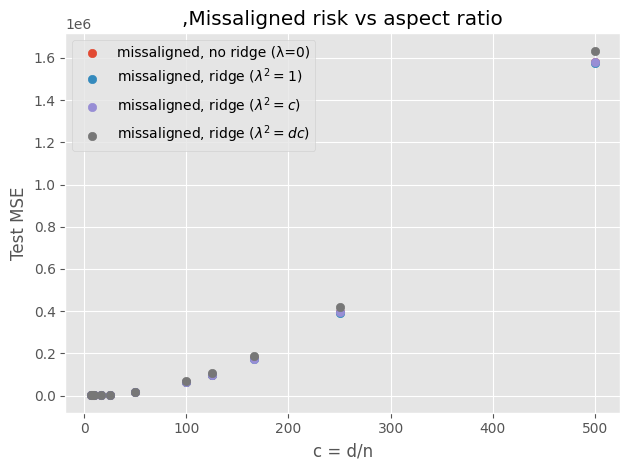

In [ ]:
plt.figure()
plt.scatter(cs, errs_noridge_align.cpu().numpy(), label="missaligned, no ridge (λ=0)")
plt.scatter(cs, errs_ridge_const.cpu().numpy(),      label=r"missaligned, ridge ($\lambda^2 = 1$)")
plt.scatter(cs, errs_ridge_c1.cpu().numpy(),      label=r"missaligned, ridge ($\lambda^2 = c$)")
# plt.scatter(cs, errs_ridge_c2.cpu().numpy(),      label=r"aligned, ridge ($\lambda^2 = c^2$)")
# plt.scatter(cs, errs_ridge_c4.cpu().numpy(),      label=r"aligned, ridge ($\lambda^2 = c^4$)")
plt.scatter(cs, errs_ridge_d.cpu().numpy(),      label=r"missaligned, ridge ($\lambda^2 = dc$)")
# plt.scatter(cs, errs_ridge_dc2.cpu().numpy(),      label=r"aligned, ridge ($\lambda^2 = dc^2$)")


plt.xlabel("c = d/n")
plt.ylabel("Test MSE")
# plt.xscale("log")
# plt.yscale("log")
plt.title(r",Missaligned risk vs aspect ratio")
plt.legend()
plt.tight_layout()
plt.show()

# Alignment Plots

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---- Building blocks ----

class MLPResidualBlock(nn.Module):
    """
    Pre-norm residual MLP block:
      y = x + FF(LN(x)),     FF = Linear -> Act -> Dropout -> Linear -> Dropout
    Optionally uses a bottleneck to reduce params/compute.
    """
    def __init__(self, dim, bottleneck=None, dropout=0.0, activation="gelu", use_layernorm=True):
        super().__init__()
        self.use_ln = use_layernorm
        self.ln = nn.LayerNorm(dim) if use_layernorm else nn.Identity()
        hidden = bottleneck if (bottleneck is not None and bottleneck > 0) else dim

        self.fc1 = nn.Linear(dim, hidden)
        self.fc2 = nn.Linear(hidden, dim)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

        if activation.lower() == "relu":
            self.act = nn.ReLU()
        elif activation.lower() == "tanh":
            self.act = nn.Tanh()
        elif activation.lower() == "silu":
            self.act = nn.SiLU()
        else:
            self.act = nn.GELU()  # default

    def forward(self, x):
        h = self.ln(x) if self.use_ln else x
        h = self.fc1(h)
        h = self.act(h)
        h = self.dropout1(h)
        h = self.fc2(h)
        h = self.dropout2(h)
        return x + h


class ResidualMLP(nn.Module):
    """
    Deeper MLP with:
      - Input projection
      - Stack of residual MLP blocks
      - Optional LayerNorm before head
      - Output head
    """
    def __init__(
        self,
        input_size=750,
        hidden_size=1024,
        output_size=1,
        depth=8,
        bottleneck=None,      # e.g., 256 for bottlenecked FFNs; None to use full hidden_size
        dropout=0.1,
        activation="gelu",
        prenorm=True,         # if True, blocks use LayerNorm (pre-norm)
        final_layernorm=False # if True, add LN before output head
    ):
        super().__init__()
        self.in_proj = nn.Linear(input_size, hidden_size)

        blocks = []
        for _ in range(depth):
            blocks.append(
                MLPResidualBlock(
                    dim=hidden_size,
                    bottleneck=bottleneck,
                    dropout=dropout,
                    activation=activation,
                    use_layernorm=prenorm
                )
            )
        self.blocks = nn.Sequential(*blocks)
        self.out_ln = nn.LayerNorm(hidden_size) if final_layernorm else nn.Identity()
        self.head = nn.Linear(hidden_size, output_size)

        # Kaiming initialization for better stability
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, a=0.01)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.in_proj(x)
        x = self.blocks(x)
        x = self.out_ln(x)
        return self.head(x)

# ---- Factory ----

def get_model(
    input_size=750,
    hidden_size=1024,
    output_size=1,
    depth=3,
    bottleneck=256,
    dropout=0.1,
    activation="gelu",
    prenorm=True,
    final_layernorm=False
):
    """
    More complicated model than a plain 3-layer MLP:
      - depth residual stack
      - (optional) bottlenecked feed-forward
      - LayerNorm + Dropout
      - Configurable activation
    """
    return ResidualMLP(
        input_size=input_size,
        hidden_size=hidden_size,
        output_size=output_size,
        depth=depth,
        bottleneck=bottleneck,
        dropout=dropout,
        activation=activation,
        prenorm=prenorm,
        final_layernorm=final_layernorm,
    )

# Example:
# model = get_model(input_size=750, hidden_size=1024, depth=10, bottleneck=256, dropout=0.1, activation="gelu")


In [ ]:
# def get_model(input_size=750, hidden_size=1000, output_size=1):
#   return torch.nn.Sequential(
#     torch.nn.Linear(input_size, hidden_size),
#     torch.nn.ReLU(),
#     torch.nn.Linear(hidden_size, hidden_size),
#     torch.nn.ReLU(),
#     torch.nn.Linear(hidden_size, output_size)
#   )

def train_model(X, y, model, epochs=100, learning_rate=0.0001):
  """Trains a PyTorch model using gradient descent.

  Args:
    X: The input features.
    y: The target variable.
    model: The PyTorch model to train.
    epochs: The number of training epochs.
    learning_rate: The learning rate for the optimizer.

  Returns:
    The trained PyTorch model.
  """

  # Define the loss function and optimizer
  criterion = torch.nn.MSELoss()
  optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

  # Train the model
  for epoch in range(epochs):
    # Forward pass
    outputs = model(X)
    loss = criterion(outputs, y)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print the loss for monitoring
    # if (epoch + 1) % 1 == 0:
    #   print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}')

  return model

In [ ]:
n = 500
d = 750

tau = np.sqrt(d)
alpha_A = 10
alpha_A_t = 1
alpha_Z = 10
alpha_Z_t = 1
tau_e = 1

beta_star = torch.randn(d,1)
beta_star = beta_star/torch.norm(beta_star)

angles = [0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90]
T = 5

errors = torch.zeros(len(angles))
error_decomp = torch.zeros(4,len(angles))

bias_theory_formula = torch.zeros(len(angles))
noise_theory_formula = torch.zeros(len(angles))
variance_theory_formula = torch.zeros(len(angles))
alignment_theory_formula = torch.zeros(len(angles))

theorys = torch.zeros(len(angles))
theorys_decomp = torch.zeros(4,len(angles))


for i,angle in list(enumerate(angles)):

  u = generate_angle_vector(beta_star, angle)

  align = (beta_star.T @ u)**2
  Delta = (alpha_A - alpha_Z)
  c = d/n

  v = torch.randn(n,1)
  v = v/torch.norm(v)

  v_t = torch.randn(n,1)
  v_t = v_t/torch.norm(v_t)

  theta = np.sqrt(n) * tau
  theta_t = np.sqrt(n) * tau

  # theorys[i] = theory(n, d, tau, beta_star, u, theta, theta_t, alpha_A, alpha_A_t, alpha_Z, alpha_Z_t, tau_e)

  # theorys_decomp[0,i] = bias_theory(n, d, tau, beta_star, u, theta, theta_t, alpha_A, alpha_A_t, alpha_Z, alpha_Z_t, tau_e)
  # theorys_decomp[1,i] = noise_theory(n, d, tau, beta_star, u, theta, theta_t, alpha_A, alpha_A_t, alpha_Z, alpha_Z_t, tau_e)
  # theorys_decomp[2,i] = variance_theory(n, d, tau, beta_star, u, theta, theta_t, alpha_A, alpha_A_t, alpha_Z, alpha_Z_t, tau_e)
  # theorys_decomp[3,i] = alignment_theory(n, d, tau, beta_star, u, theta, theta_t, alpha_A, alpha_A_t, alpha_Z, alpha_Z_t, tau_e)
  for _ in tqdm(range(T)):
    A = torch.randn(d,n) * (tau / np.sqrt(d))
    Z = theta * u @ v.T
    X = Z + A

    y = beta_star.T @ (alpha_Z * Z + alpha_A * A)
    y = y + torch.randn_like(y) * tau_e
    # beta = (y @ torch.linalg.pinv(X)).T
    model = get_model()
    model = train_model(X.T, y.T, model)

    A_t = torch.randn(d,n) * (tau / np.sqrt(d))
    Z_t = theta_t * u @ v_t.T
    X_t = alpha_Z_t * Z_t + alpha_A_t * A_t
    y_t = beta_star.T @ X_t

    # y_p = beta.T @ (Z_t + A_t)
    y_p = model((Z_t + A_t).T).T

    errors[i] += (y_p - y_t).square().sum().detach()/(n*T)

    # error_decomp[0, i] += (beta_star.T @ (alpha_Z_t * Z_t) - beta.T @ Z_t).square().sum()/(n*T)
    # error_decomp[1, i] += (alpha_A_t * beta_star.T @ A_t).square().sum()/(n*T)
    # error_decomp[2, i] += (beta.T @ A_t).square().sum()/(n*T)
    # error_decomp[3, i] -= 2*(alpha_A_t * beta_star.T @ A_t @ A_t.T @ beta).item()/(n*T)

100%|██████████| 5/5 [00:01<00:00,  2.59it/s]


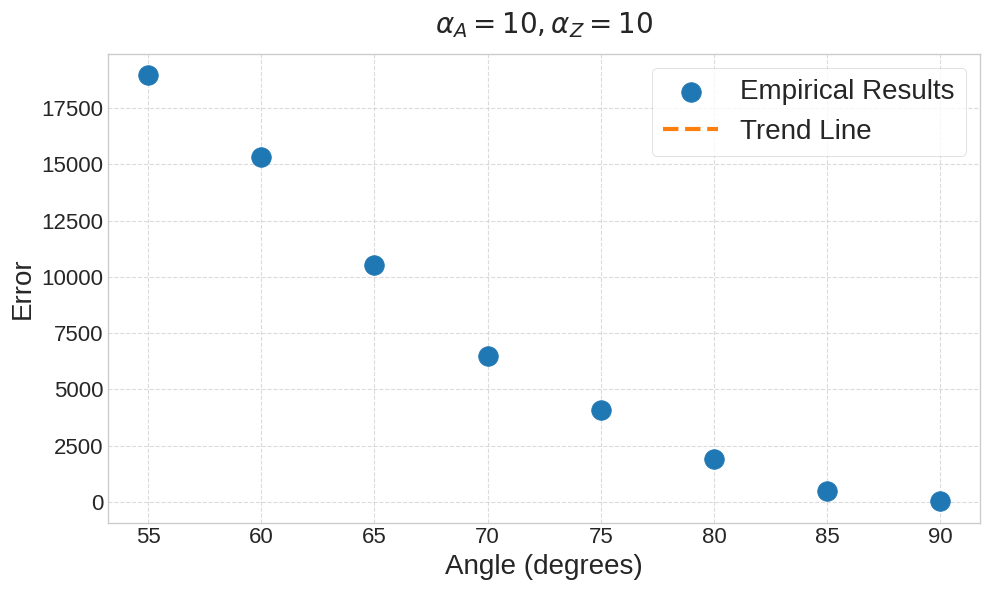

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# Set a professional style
plt.style.use('seaborn-v0_8-whitegrid')

# Increase figure size and DPI for better visibility
plt.figure(figsize=(10, 6), dpi=100)

# Create the scatter plot with improved aesthetics
plt.scatter(angles, errors.detach().cpu(), label="Empirical Results",
           color='#1f77b4', s=200, linewidths=0.5)

# Add a trend line to highlight the pattern
z = np.polyfit(angles, errors.detach().cpu().numpy(), 12)
p = np.poly1d(z)
x_trend = np.linspace(min(angles), max(angles), 100)
plt.plot(x_trend, p(x_trend), '--', color='#ff7f0e', linewidth=3,
         label=f"Trend Line")

# Clean up title with more informative content
plt.title(f"$α_A = {alpha_A}, α_Z = {alpha_Z}$",
          fontsize=20, pad=15)

# Improve axis labels
plt.xlabel("Angle (degrees)", fontsize=20)
plt.ylabel("Error", fontsize=20)

# plt.yscale("log")

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Enhance the legend
plt.legend(frameon=True, fontsize=20, loc='best')

# Add grid for easier reading of values
plt.grid(True, linestyle='--', alpha=0.7)

# Add a text box with parameters
# props = dict(boxstyle='round', facecolor='white', alpha=0.5)
# plt.text(0.05, 0.95, "Parameters:\nα_A = 1, \nα_Z = 4\n3-layer ReLU",
#          transform=plt.gca().transAxes, fontsize=20,
#          verticalalignment='top', bbox=props)

# Tight layout to ensure everything fits well
plt.tight_layout()

# Save the figure with high resolution if needed
plt.savefig('error_vs_angle_plot-large-alpha_z-3-network.png', dpi=100, bbox_inches='tight')

plt.show()

# MNIST

In [ ]:
# ==== MNIST-as-bulk utilities ====
# Requires: torchvision
import torch, numpy as np
from torchvision import datasets, transforms

def _sample_mnist_matrix(n, split="train", device="cpu"):
    """
    Return raw columns X_raw \in R^{784 x n} from MNIST (values in [0,1]).
    """
    ds = datasets.MNIST(root="./data", train=(split=="train"), download=True,
                        transform=transforms.ToTensor())
    idx = torch.randint(0, len(ds), (n,))
    # Stack images into (784, n)
    X = torch.stack([ds[i][0].squeeze().reshape(-1) for i in idx], dim=1).to(device)  # (784, n)
    return X.float()

def _whiten_reduce_scale(X_raw, d, tau, eps=1e-6):
    """
    Center, whiten, reduce to first d whitened components, then scale so that
    Var(each bulk coord) ≈ tau^2 / d, matching A ~ N(0, (tau/sqrt(d))^2).
    Inputs:
      X_raw: (D0, n), e.g. D0=784
    Returns:
      A: (d, n)
    """
    # Center
    X = X_raw - X_raw.mean(dim=1, keepdim=True)  # (D0, n)
    n = X.shape[1]

    # SVD on normalized data (X / sqrt(n)) -> whitening
    # X / sqrt(n) = U S V^T, covariance = U S^2 U^T
    U, S, Vh = torch.linalg.svd(X / np.sqrt(n), full_matrices=False)
    # Whiten: U^T X / S  (add tiny eps for stability)
    Xw = (U.T @ X) / (S[:, None] + eps)  # (D0, n), approx identity covariance

    # Reduce to top-d whitened coords
    if d > Xw.shape[0]:
        raise ValueError(f"d={d} exceeds available MNIST dims {Xw.shape[0]}")
    A = Xw[:d, :]

    # Scale so per-coordinate variance matches tau^2 / d
    # After whitening, each row of Xw has ~ unit variance; target std = tau/sqrt(d)
    A = (tau / np.sqrt(d)) * A
    return A

def mnist_bulk(d, n, tau, split="train", device="cpu"):
    """
    Convenience wrapper: sample MNIST columns and produce bulk A \in R^{d x n}
    with approx Var(A_ij)=tau^2/d, analogous to your Gaussian A.
    """
    A = _sample_mnist_matrix(n, split=split, device=device)  # (784, n)
    # A = _whiten_reduce_scale(X_raw, d=d, tau=tau)
    return A

# ==== Minimal training loop for your model (if you don't already have train_model) ====
# import torch.nn as nn

# def train_model(X, y, model, epochs=100, lr=1e-4, weight_decay=0.0, batch_size=None, device="cpu"):
#     """
#     X: (n, d), y: (n, 1)
#     """
#     model = model.to(device)
#     X = X.to(device); y = y.to(device)
#     opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
#     loss_fn = nn.MSELoss()

#     if batch_size is None or batch_size >= X.shape[0]:
#         # full-batch
#         for _ in range(epochs):
#             opt.zero_grad()
#             pred = model(X)
#             loss = loss_fn(pred, y)
#             loss.backward()
#             opt.step()
#     else:
#         # mini-batch
#         n = X.shape[0]
#         idx = torch.arange(n, device=device)
#         for _ in range(epochs):
#             perm = idx[torch.randperm(n)]
#             for start in range(0, n, batch_size):
#                 sel = perm[start:start+batch_size]
#                 xb, yb = X[sel], y[sel]
#                 opt.zero_grad()
#                 loss = loss_fn(model(xb), yb)
#                 loss.backward()
#                 opt.step()
#     return model


<>:8: SyntaxWarning: invalid escape sequence '\i'
<>:48: SyntaxWarning: invalid escape sequence '\i'
<>:8: SyntaxWarning: invalid escape sequence '\i'
<>:48: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipython-input-2873480074.py:8: SyntaxWarning: invalid escape sequence '\i'
  Return raw columns X_raw \in R^{784 x n} from MNIST (values in [0,1]).
/tmp/ipython-input-2873480074.py:48: SyntaxWarning: invalid escape sequence '\i'
  Convenience wrapper: sample MNIST columns and produce bulk A \in R^{d x n}


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

n = 1000
d = 784

beta_star = torch.randn(d,1)
beta_star = beta_star/torch.norm(beta_star)

errors = torch.zeros(len(angles))

alpha_A = 1
alpha_A_t = 1
alpha_Z = 4
alpha_Z_t = 4
tau_e = 1

for i, angle in list(enumerate(angles)):
    u = generate_angle_vector(beta_star, angle)
    c = d/n

    v   = torch.randn(n,1, device=device); v   = v/torch.norm(v)
    v_t = torch.randn(n,1, device=device); v_t = v_t/torch.norm(v_t)

    theta   = np.sqrt(n) * tau
    theta_t = np.sqrt(n) * tau

    for _ in tqdm(range(5)):
        # --- bulk from MNIST instead of Gaussian ---
        A  = mnist_bulk(d=d, n=n, tau=tau, split="train", device=device)     # (d,n)
        Z  = theta   * (u.to(device) @ v.T)                                   # (d,n)
        X  = Z + A

        y  = beta_star.to(device).T @ (alpha_Z * Z + alpha_A * A)             # (1,n)
        y  = y + torch.randn_like(y) * tau_e

        model = get_model(input_size=d, hidden_size=1024, output_size=1)      # adapt input_size=d
        model = train_model(X.T, y.T, model)

        # --- test bulk from MNIST test split ---
        A_t = mnist_bulk(d=d, n=n, tau=tau, split="test", device=device)      # (d,n)
        Z_t = theta_t * (u.to(device) @ v_t.T)                                 # (d,n)
        X_t = alpha_Z_t * Z_t + alpha_A_t * A_t
        y_t = beta_star.to(device).T @ X_t                                     # (1,n)

        y_p = model((Z_t + A_t).T).T                                           # (1,n)

        errors[i] += (y_p - y_t).square().sum().detach()/(n*5)


100%|██████████| 5/5 [00:04<00:00,  1.12it/s]


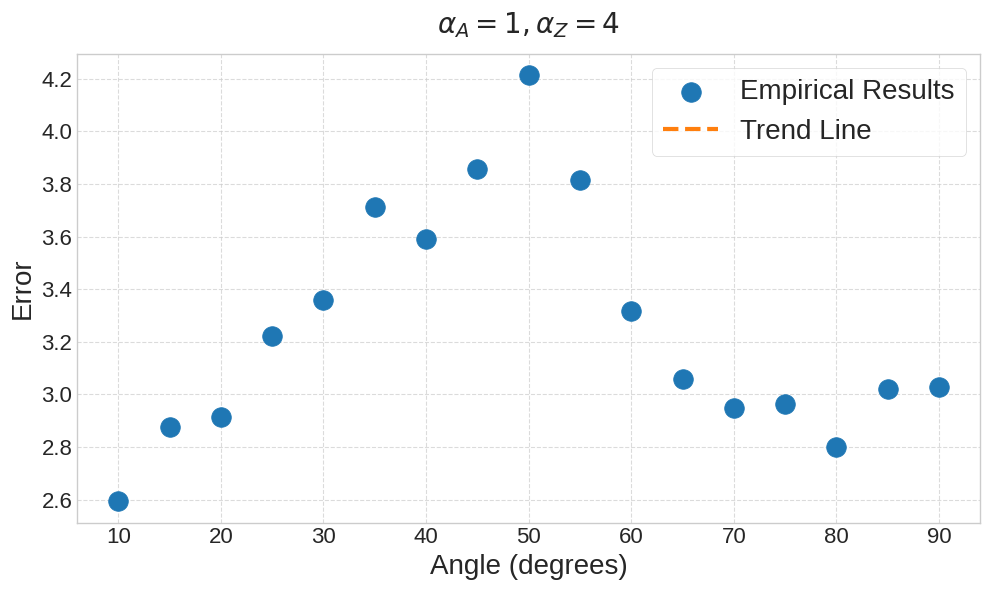

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# Set a professional style
plt.style.use('seaborn-v0_8-whitegrid')

# Increase figure size and DPI for better visibility
plt.figure(figsize=(10, 6), dpi=100)

# Create the scatter plot with improved aesthetics
plt.scatter(angles, errors.detach().cpu(), label="Empirical Results",
           color='#1f77b4', s=200, linewidths=0.5)

# Add a trend line to highlight the pattern
z = np.polyfit(angles, errors.detach().cpu().numpy(), 12)
p = np.poly1d(z)
x_trend = np.linspace(min(angles), max(angles), 100)
plt.plot(x_trend, p(x_trend), '--', color='#ff7f0e', linewidth=3,
         label=f"Trend Line")

# Clean up title with more informative content
plt.title(f"$α_A = {alpha_A}, α_Z = {alpha_Z}$",
          fontsize=20, pad=15)

# Improve axis labels
plt.xlabel("Angle (degrees)", fontsize=20)
plt.ylabel("Error", fontsize=20)

# plt.yscale("log")

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Enhance the legend
plt.legend(frameon=True, fontsize=20, loc='best')

# Add grid for easier reading of values
plt.grid(True, linestyle='--', alpha=0.7)

# Add a text box with parameters
# props = dict(boxstyle='round', facecolor='white', alpha=0.5)
# plt.text(0.05, 0.95, "Parameters:\nα_A = 1, \nα_Z = 4\n3-layer ReLU",
#          transform=plt.gca().transAxes, fontsize=20,
#          verticalalignment='top', bbox=props)

# Tight layout to ensure everything fits well
plt.tight_layout()

# Save the figure with high resolution if needed
plt.savefig('error_vs_angle_plot-large-alpha_z-3-network.png', dpi=100, bbox_inches='tight')

plt.show()